
### Reproducing Figure 4d

* Run the simulated annealing pipeline: `scripts/simulated-annealing-monte-carlo/sa_desktop.py`.

* This generates several Excel output files, including: `150n_e4_all_runs.xlsx`.

* Use `150n_e4_all_runs.xlsx` as the input for the plotting script that plots the first N runs (the second script below).

* Update the path in:

  .

* Run the script. It reads the `final_cell_energy` column from the first `N_SHEETS` worksheets and generates the energy-evolution plot used in Figure 4d.

### Parameters for Figure 4d

This controls how many of the first simulation runs are plotted.

* `N_SHEETS = 5` plots the first five runs (used for Figure 4d).

* `N_SHEETS = 10` plots the first ten runs.

### Alternative: Plot Random Runs

The first script is an alternative visualization and was not used to generate Figure 4d.

It randomly selects a subset of worksheets from `150n_e4_all_runs.xlsx` and plots their energy trajectories.

Useful parameters:

Changing `N_RANDOM_SHEETS` changes how many random runs are displayed, and changing `RANDOM_SEED` changes which runs are selected.




### Figure 4d

Plotting first 5 sheets: ['Run_1', 'Run_2', 'Run_3', 'Run_4', 'Run_5']
Figure saved as /Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/paper_figures/SA/energy_evolution_random_runs2.pdf


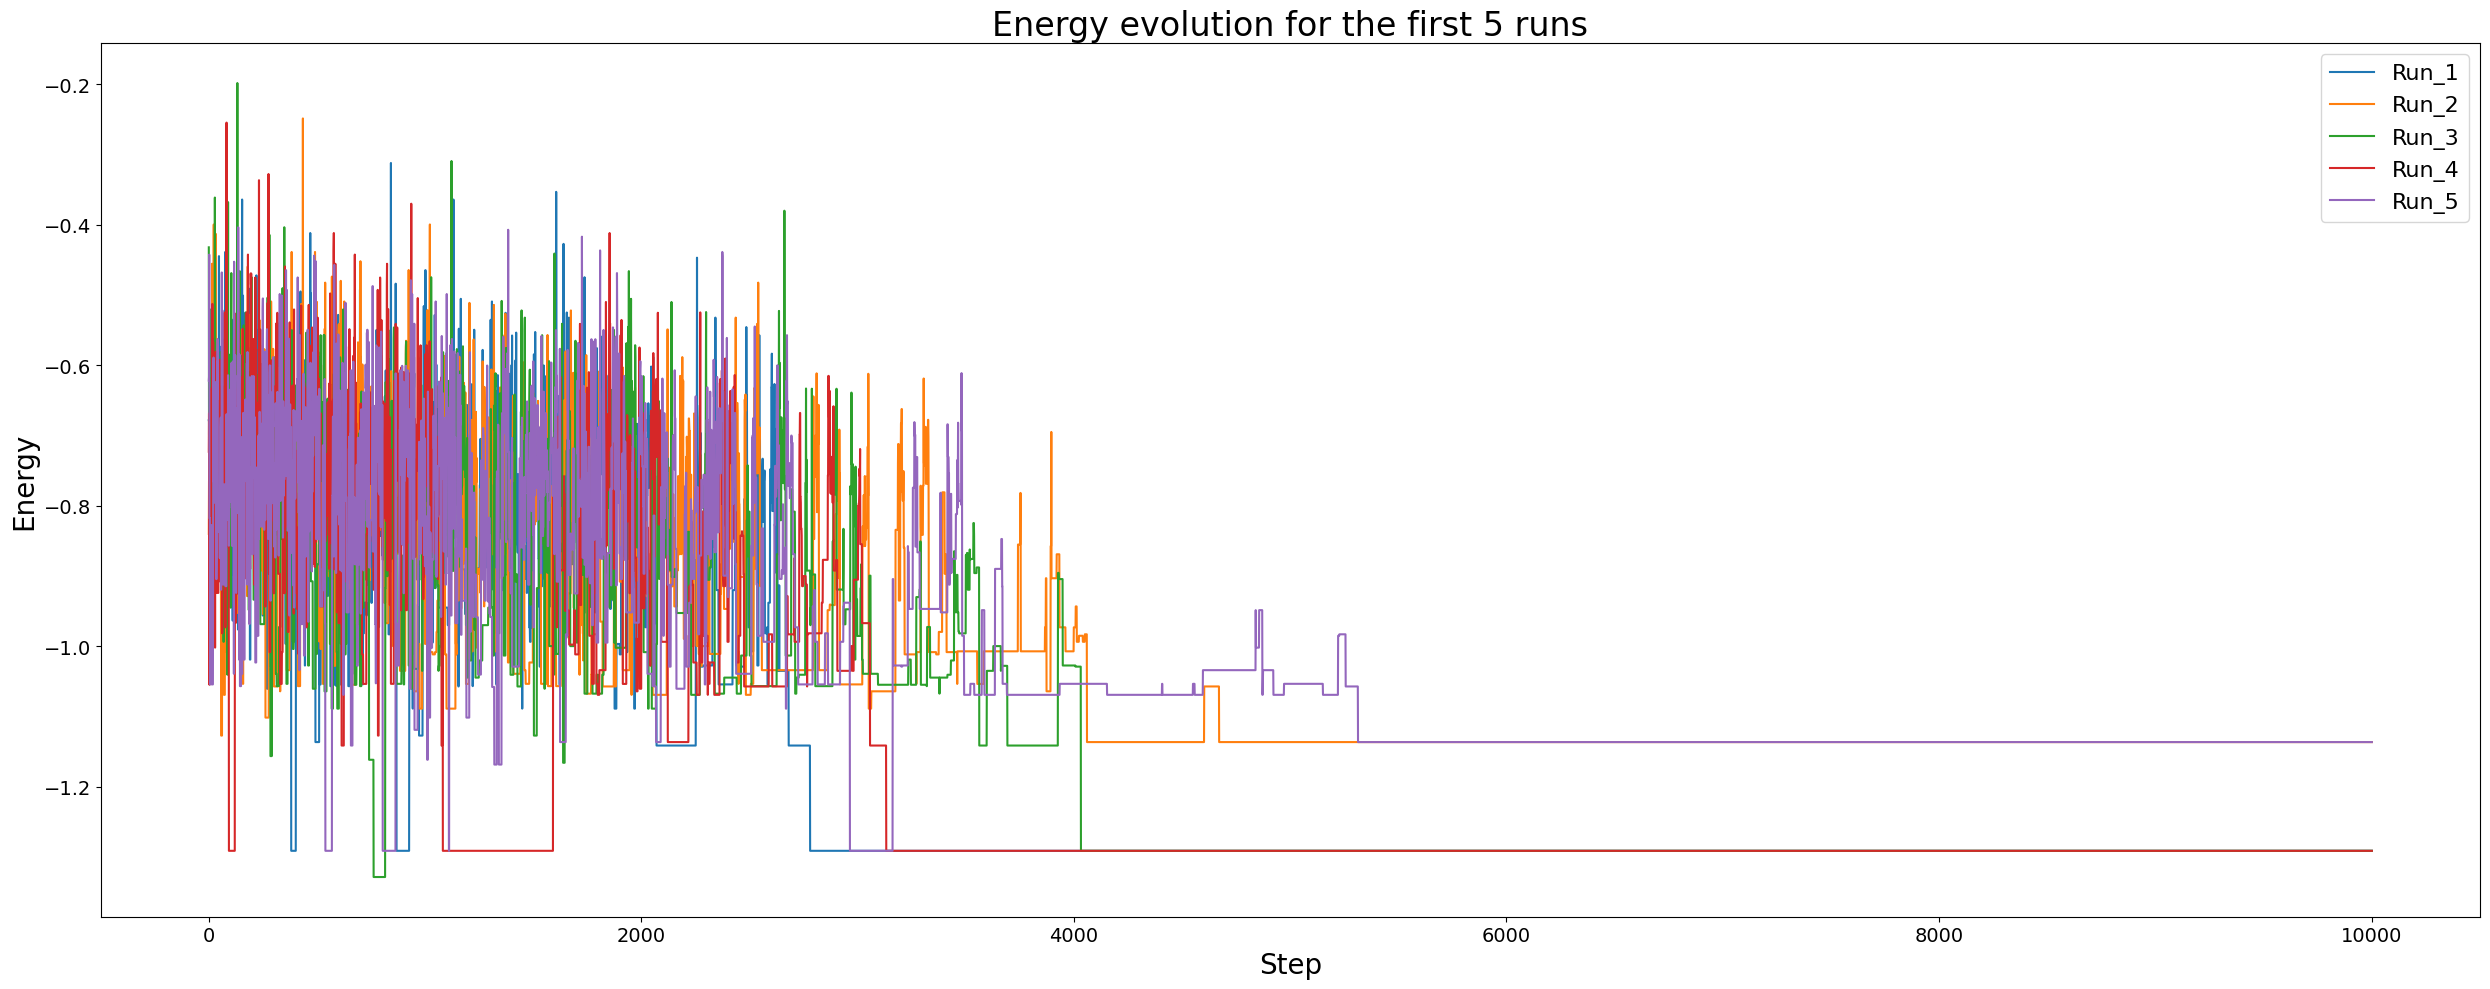

In [8]:



#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt

# ==================== CONFIGURATION ====================
EXCEL_FILE = "/Users/mozhganoroujlu/Desktop/SA/score/results/modif/generated/all_opcs/150n_e4_all_runs.xlsx"
N_SHEETS = 5                     # Number of sheets to plot (first N)
OUTPUT_PDF = "/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/paper_figures/SA/energy_evolution_random_runs2.pdf"  # Name of the output PDF file
# =======================================================
# Font sizes for better visibility on a large figure
FONTS = {
    'title': 24,
    'label': 20,
    'legend': 16,
    'tick': 14
}
# =======================================================

# Read sheet names from the Excel file
xl = pd.ExcelFile(EXCEL_FILE)
sheet_names = xl.sheet_names[:N_SHEETS]   # Take the first N sheets

print(f"Plotting first {N_SHEETS} sheets: {sheet_names}")

# Create figure
plt.figure(figsize=(25, 10))

# Loop over the first N sheets
for sheet in sheet_names:
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    
    if 'final_cell_energy' not in df.columns:
        print(f"Warning: Sheet '{sheet}' has no 'final_cell_energy' column. Skipping.")
        continue
    
    energy = df['final_cell_energy'].values
    steps = range(1, len(energy) + 1)   # step 1 = Excel row 2
    plt.plot(steps, energy, label=sheet)

# Apply font sizes
plt.xlabel("Step", fontsize=FONTS['label'])
plt.ylabel("Energy", fontsize=FONTS['label'])
plt.title(f"Energy evolution for the first {N_SHEETS} runs", fontsize=FONTS['title'])
plt.legend(fontsize=FONTS['legend'])

# Adjust tick label sizes
plt.xticks(fontsize=FONTS['tick'])
plt.yticks(fontsize=FONTS['tick'])

plt.grid(False)
plt.tight_layout()

# Save and show
plt.savefig(OUTPUT_PDF, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved as {OUTPUT_PDF}")
plt.show()

### Alternative: Plot Random Runs

Randomly selected sheets: ['Run_276', 'Run_130', 'Run_523', 'Run_242', 'Run_1015']
Figure saved as /Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/paper_figures/SA/energy_evolution_random_runs1.pdf


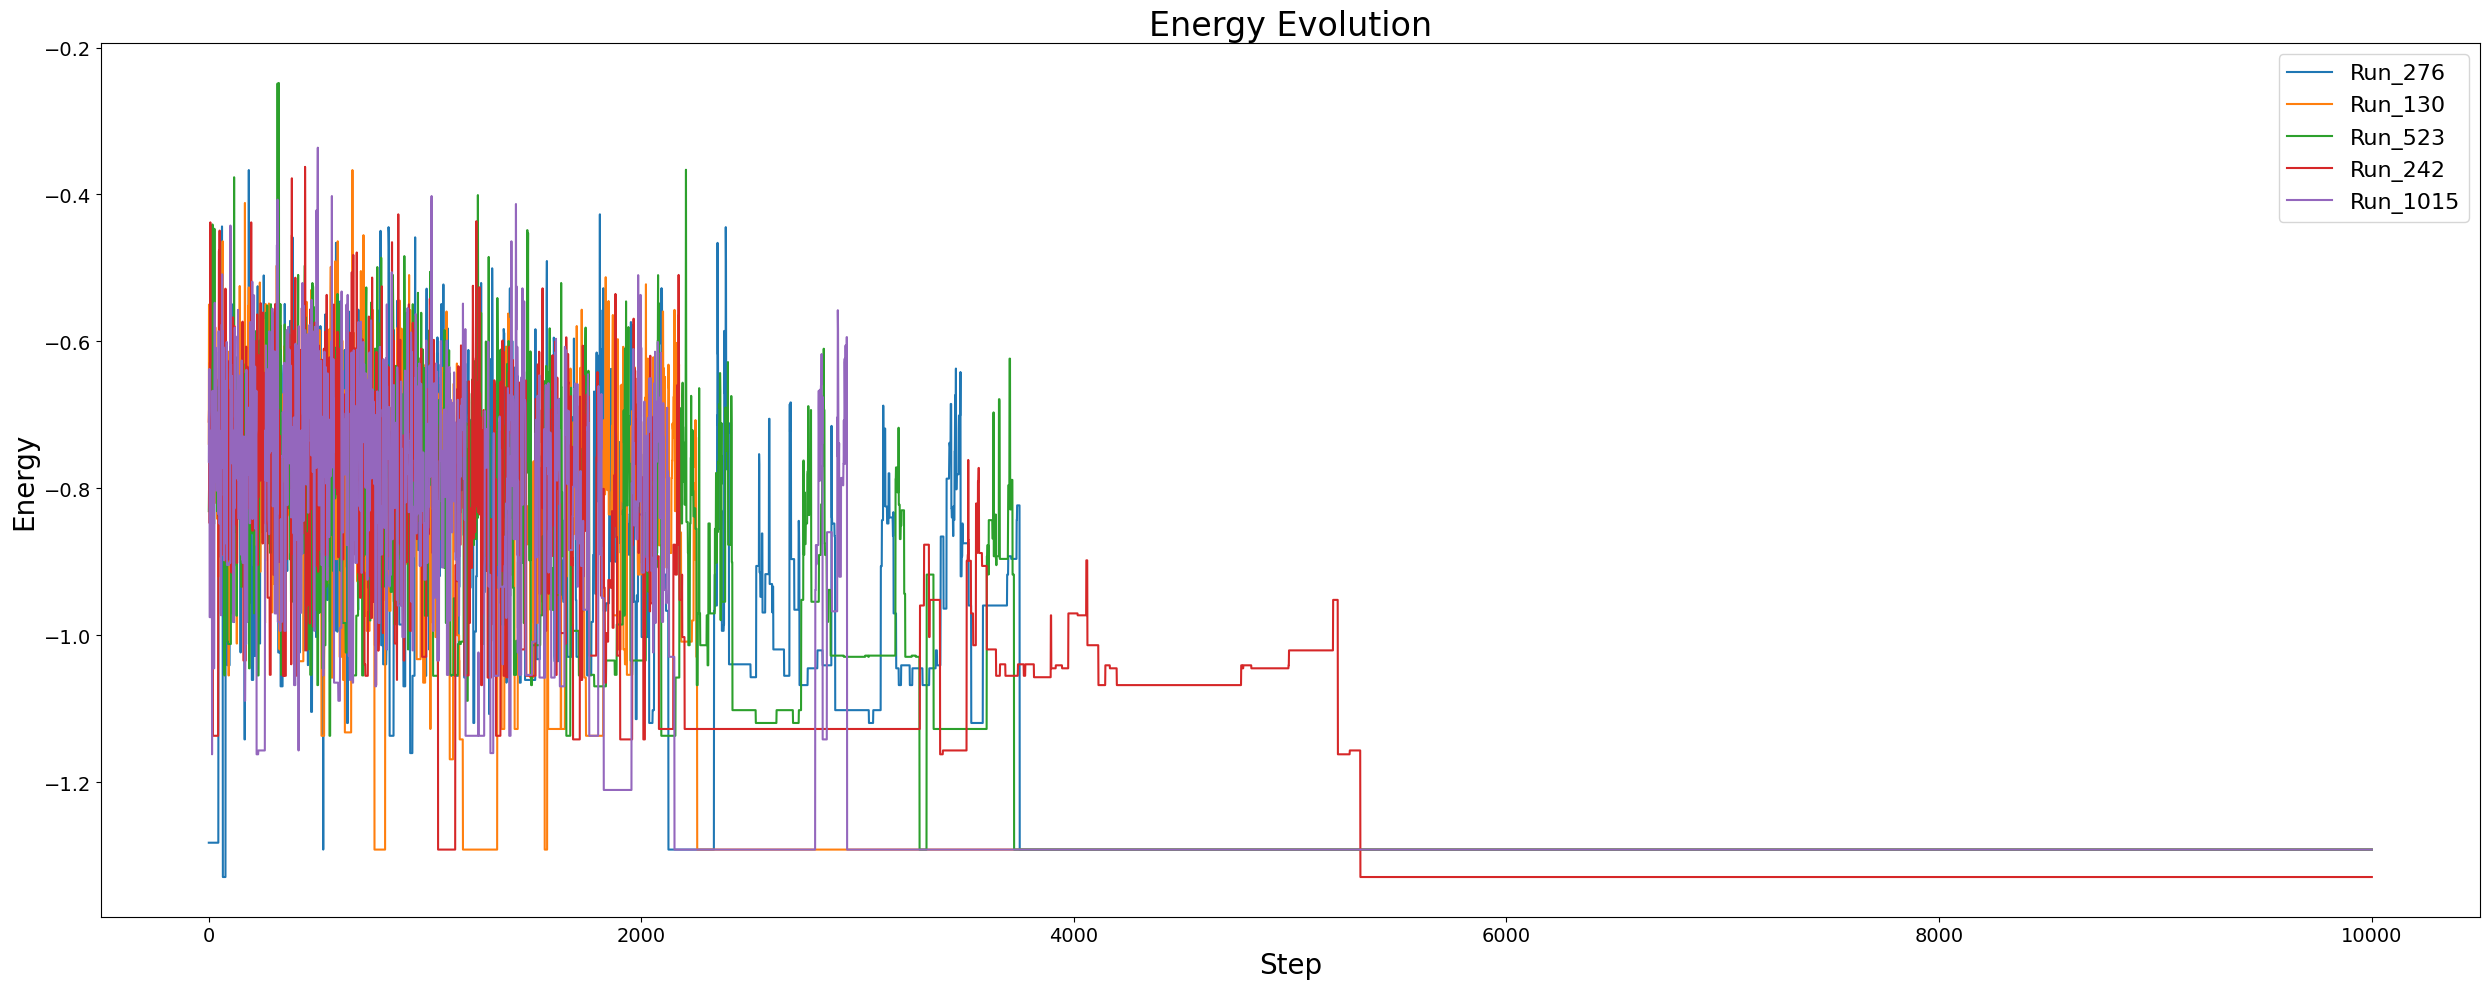

In [6]:


import pandas as pd
import matplotlib.pyplot as plt
import random

# ==================== CONFIGURATION ====================
EXCEL_FILE = "/Users/mozhganoroujlu/Desktop/SA/score/results/modif/generated/all_opcs/150n_e4_all_runs.xlsx"
N_RANDOM_SHEETS = 5
RANDOM_SEED = True
OUTPUT_PDF = "/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/paper_figures/SA/energy_evolution_random_runs1.pdf"  # Name of the output PDF file
# =======================================================
# Font sizes for better visibility on a large figure
FONTS = {
    'title': 24,
    'label': 20,
    'legend': 16,
    'tick': 14
}
# =======================================================

# Read all sheet names
xl = pd.ExcelFile(EXCEL_FILE)
all_sheet_names = xl.sheet_names

# Random selection
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
selected_sheets = random.sample(all_sheet_names, min(N_RANDOM_SHEETS, len(all_sheet_names)))

print(f"Randomly selected sheets: {selected_sheets}")

# Create figure
plt.figure(figsize=(25, 10))

# Plot each run
for sheet in selected_sheets:
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    if 'final_cell_energy' not in df.columns:
        print(f"Warning: Sheet '{sheet}' has no 'final_cell_energy' column. Skipping.")
        continue
    
    energy = df['final_cell_energy'].values
    steps = range(1, len(energy) + 1)
    plt.plot(steps, energy, label=sheet)

# Apply font sizes
plt.xlabel("Step", fontsize=FONTS['label'])
plt.ylabel("Energy", fontsize=FONTS['label'])
plt.title(f"Energy Evolution", fontsize=FONTS['title'])
plt.legend(fontsize=FONTS['legend'])

# Adjust tick label sizes
plt.xticks(fontsize=FONTS['tick'])
plt.yticks(fontsize=FONTS['tick'])

plt.grid(False)
plt.tight_layout()

# Save and show
plt.savefig(OUTPUT_PDF, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved as {OUTPUT_PDF}")
plt.show()